<a href="https://colab.research.google.com/github/sid17905/DL-PAPER-IMPLEMENTATION/blob/main/DL_PAPER_PROJECT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# A Novel Early Detection and Prevention of Coronary Heart Disease (CHD) Framework
## Hybrid Deep Learning Model (O-SBGC-LSTM) + Neural Fuzzy Inference System (FLCHDCS)

> **Paper:** *A Novel Early Detection and Prevention of Coronary Heart Disease Framework Using Hybrid Deep Learning Model and Neural Fuzzy Inference System*

> **Dataset:** [Kaggle Cardiovascular Disease Dataset](https://www.kaggle.com/datasets/sulianova/cardiovascular-disease-dataset)  `sulianova/cardiovascular-disease-dataset`

> **Technologies:** TensorFlow/Keras, scikit-fuzzy, NumPy, Pandas, scikit-learn, Matplotlib, Seaborn

> **Author:** AI Engineer

## Estimated Runtime

Measured on the real 68,024-row dataset (1 CPU core, TensorFlow-CPU, custom SBGC-LSTM cell -- **not** cuDNN-accelerated): **~10 s/epoch** steady-state, ~17 s for the first epoch of any given model (graph tracing).

| Stage | What runs | Approx. time (CPU, 1 core) | Approx. time (Colab T4 GPU) |
|---|---|---|---|
| Install deps | `pip install scikit-fuzzy tensorflow scikit-learn` | 1-2 min | 1-2 min |
| Data load + preprocess + graph/clustering | Cells 6-14 | < 5 s | < 5 s |
| EOA hyperparameter search | `pop_size=4 x n_iter=3` = 12 model fits x 3 epochs | ~6-8 min | ~2-4 min |
| Final model training | up to 60 epochs, early-stopping (patience=8) | ~4-10 min | ~2-5 min |
| Evaluation, ROC, fuzzy system, plots | Cells 24-38 | < 1 min | < 1 min |
| **Total** | | **~12-20 min** | **~6-12 min** |

Notes:
- The custom graph-convolution LSTM cell is a subclassed `layers.RNN`, so it doesn't get TensorFlow's fused cuDNN LSTM kernel -- GPU speedup is real but more modest than for a plain `keras.layers.LSTM`.
- Every EOA candidate rebuilds the model with different `lstm_units`, so each of the 12 fitness evaluations re-triggers graph tracing (the ~17 s first-epoch cost), not just the very first one.
- To make this faster for a quick smoke-test, lower `EOA(pop_size=..., n_iter=...)` in cell 20, or the final `epochs=` in cell 22 -- accuracy will drop accordingly.

## 1. Install Dependencies

In [1]:
%%capture
!pip install -q scikit-fuzzy tensorflow scikit-learn


## 2. Imports and Reproducibility

In [2]:
import warnings
warnings.filterwarnings('ignore')

import os, copy, time, math, base64, gzip
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import backend as K
from tensorflow.keras import layers

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, auc
)

import skfuzzy as fuzz
from skfuzzy import control as ctrl

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

print(f'TensorFlow version : {tf.__version__}')
print(f'NumPy version      : {np.__version__}')
print(f'Pandas version     : {pd.__version__}')

TensorFlow version : 2.20.0
NumPy version      : 2.1.3
Pandas version     : 2.2.3


## 3. Data Loading

We use the **sulianova/cardiovascular-disease-dataset** from Kaggle (70,000-patient cardiovascular records) -- the exact dataset named in the paper. A cleaned copy of the real CSV (68,024 records) is embedded directly in the next cell (gzip + base64), so the notebook runs standalone with no Kaggle login or manual upload. If a `cardio_train.csv` already sits next to the notebook, that file is used instead; synthetic data is only generated as an absolute last resort.

In [3]:
CSV_PATH = 'cardio_train.csv'

# ==================================================================
# Embedded REAL dataset: Kaggle "Cardiovascular Disease dataset" by
# Svetlana Ulianova (sulianova/cardiovascular-disease-dataset) -- the
# exact dataset named in the paper (Section IV): 70,000 patient
# records, target `cardio`, schema = age, gender, height, weight,
# ap_hi, ap_lo, cholesterol, gluc, smoke, alco, active, cardio.
#
# The CSV is embedded here (gzip + base64) so the notebook is fully
# self-contained and reproducible without a Kaggle login, API token,
# or manual upload step. It decodes to a semicolon-delimited CSV of
# 68,024 records (a small number of duplicate/placeholder rows were
# already removed upstream), which matches the feature ranges and
# ~50/50 cardio class balance reported for this dataset.
#
# If you'd rather use your own copy (e.g. the untouched 70,000-row
# file straight from Kaggle), just place `cardio_train.csv` next to
# this notebook -- the loader below prefers a local file over the
# embedded copy automatically.
# ==================================================================
_CARDIO_CSV_GZ_B64 = """
...
3RcykxGFajL92G7vR+L/Moz1azyVKwA=
"""


def _materialize_embedded_dataset(path=CSV_PATH):
    """Decode the embedded gzip+base64 CSV to disk."""
    raw = base64.b64decode(_CARDIO_CSV_GZ_B64.strip())
    csv_bytes = gzip.decompress(raw)
    with open(path, 'wb') as f:
        f.write(csv_bytes)
    return path


def generate_synthetic_data(n=70000):
    """Last-resort fallback only -- mimics the dataset schema.
    Should not trigger: the real data is embedded above."""
    np.random.seed(SEED)
    d = pd.DataFrame()
    d['id']         = np.arange(n)
    d['age']        = np.random.randint(10798, 23713, n)   # age in days
    d['gender']     = np.random.randint(1, 3, n)
    d['height']     = np.random.randint(145, 201, n)
    d['weight']     = np.random.uniform(40, 180, n).round(1)
    d['ap_hi']      = np.random.randint(80, 240, n)
    d['ap_lo']      = np.random.randint(40, 160, n)
    d['cholesterol']= np.random.choice([1, 2, 3], n, p=[0.55, 0.25, 0.20])
    d['gluc']       = np.random.choice([1, 2, 3], n, p=[0.60, 0.22, 0.18])
    d['smoke']      = np.random.choice([0, 1], n, p=[0.91, 0.09])
    d['alco']       = np.random.choice([0, 1], n, p=[0.95, 0.05])
    d['active']     = np.random.choice([0, 1], n, p=[0.20, 0.80])
    risk = (0.3 * (d['ap_hi'] > 140).astype(int) +
            0.2 * (d['cholesterol'] > 1).astype(int) +
            0.15 * (d['gluc'] > 1).astype(int) +
            0.10 * (d['weight'] > 80).astype(int) +
            0.10 * (d['age'] > 18000).astype(int) +
            0.15 * np.random.rand(n))
    d['cardio'] = (risk > 0.5).astype(int)
    return d


# --- Load order: (1) a real CSV already sitting next to the notebook,
#     (2) the embedded real Kaggle dataset, (3) synthetic as a last
#     resort if decoding somehow fails. ---
try:
    df = pd.read_csv(CSV_PATH, sep=';')
    print(f'Loaded local dataset : {df.shape}')
except FileNotFoundError:
    try:
        _materialize_embedded_dataset()
        df = pd.read_csv(CSV_PATH, sep=';')
        print(f'Loaded embedded Kaggle dataset (sulianova/cardiovascular-disease-dataset) : {df.shape}')
    except Exception as exc:
        print(f'Could not decode embedded dataset ({exc}). Generating synthetic dataset instead...')
        df = generate_synthetic_data()
        print(f'Generated synthetic dataset : {df.shape}')

print(df.head())
print(f"\nTarget distribution:\n{df['cardio'].value_counts()}")


Loaded embedded Kaggle dataset (sulianova/cardiovascular-disease-dataset) : (68024, 13)
   id    age  gender  height  weight  ap_hi  ap_lo  cholesterol  gluc  smoke  \
0   0  18393       2     168    62.0    110     80            1     1      0   
1   1  20228       1     156    85.0    140     90            3     1      0   
2   2  18857       1     165    64.0    130     70            3     1      0   
3   3  17623       2     169    82.0    150    100            1     1      0   
4   4  17474       1     156    56.0    100     60            1     1      0   

   alco  active  cardio  
0     0       1       0  
1     0       1       1  
2     0       0       1  
3     0       1       1  
4     0       0       0  

Target distribution:
cardio
0    34503
1    33521
Name: count, dtype: int64


## 4. Data Pre-processing Pipeline### 4.1 Missing values (coded as zero)Instances where blood pressure / weight equal **0** are treated as missing and removed.### 4.2 DiscretizationContinuous attribute values are transformed into finite collections of intervals for the fuzzy module.

In [4]:
# --- 4.1 Remove zero-coded missing values ---
zero_sensitive = ['ap_hi', 'ap_lo', 'height', 'weight']
for c in zero_sensitive:
    df = df[df[c] != 0]
print(f'After zero removal : {df.shape}')

# --- Remove physiological outliers ---
df = df[(df['ap_hi'] > 60) & (df['ap_hi'] < 260)]
df = df[(df['ap_lo'] > 30) & (df['ap_lo'] < 180)]
df = df[(df['height'] > 120) & (df['height'] < 220)]
df = df[(df['weight'] > 30) & (df['weight'] < 250)]
print(f'After outlier removal : {df.shape}')

# --- Derived features ---
df['age_years'] = (df['age'] / 365.25).round(1)
df['bmi'] = df['weight'] / ((df['height'] / 100) ** 2)

# --- 4.2 Discretization ---
def discretize(series, n_bins=5):
    return pd.cut(series, bins=n_bins, labels=False)

for c in ['age_years', 'height', 'weight', 'ap_hi', 'ap_lo', 'bmi']:
    df[f'{c}_bin'] = discretize(df[c])

print(f'\nFinal dataset shape : {df.shape}')
df.describe()

After zero removal : (68024, 13)
After outlier removal : (68024, 13)

Final dataset shape : (68024, 21)


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,...,active,cardio,age_years,bmi,age_years_bin,height_bin,weight_bin,ap_hi_bin,ap_lo_bin,bmi_bin
count,68024.000000,68024.000000,68024.000000,68024.000000,68024.000000,68024.000000,68024.000000,68024.000000,68024.000000,68024.000000,...,68024.000000,68024.000000,68024.000000,68024.000000,68024.000000,68024.000000,68024.000000,68024.000000,68024.000000,68024.000000
mean,49963.579266,19465.426923,1.348157,164.414545,73.722753,126.465115,81.247839,1.362534,1.223686,0.087616,...,0.803511,0.492782,53.293485,27.312320,2.831265,2.006659,1.571783,1.530269,1.839057,1.086955
std,28845.624121,2468.085974,0.476389,7.816805,13.391926,16.430443,9.302353,0.677430,0.569558,0.282738,...,0.397346,0.499952,6.757414,4.924872,0.981349,0.639791,0.885234,0.762314,0.628477,0.596072
min,0.000000,10798.000000,1.000000,130.000000,40.000000,70.000000,50.000000,1.000000,1.000000,0.000000,...,0.000000,0.000000,29.600000,13.520822,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,24990.750000,17658.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,...,1.000000,0.000000,48.300000,23.875115,2.000000,2.000000,1.000000,1.000000,2.000000,1.000000
50%,49991.000000,19701.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,...,1.000000,0.000000,53.900000,26.297578,3.000000,2.000000,1.000000,1.000000,2.000000,1.000000
75%,74844.250000,21324.250000,2.000000,170.000000,82.000000,140.000000,90.000000,1.000000,1.000000,0.000000,...,1.000000,1.000000,58.400000,30.091432,4.000000,2.000000,2.000000,2.000000,2.000000,1.000000
max,99999.000000,23713.000000,2.000000,198.000000,120.000000,200.000000,120.000000,3.000000,3.000000,1.000000,...,1.000000,1.000000,64.900000,58.024202,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000


## 5. Feature Engineering and 80/20 Train-Test Split

In [5]:
FEATURES = ['age_years', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo',
            'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'bmi']
TARGET = 'cardio'

X = df[FEATURES].values.astype(np.float32)
y = df[TARGET].values.astype(np.float32)

# Handle possible NaNs
X = np.nan_to_num(X, nan=0.0)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f'X_train : {X_train_s.shape},   X_test : {X_test_s.shape}')
print(f'y_train distribution : {np.bincount(y_train.astype(int))}')
print(f'y_test  distribution : {np.bincount(y_test.astype(int))}')

X_train : (54419, 12),   X_test : (13605, 12)
y_train distribution : [27602 26817]
y_test  distribution : [6901 6704]


## 6. Graph Construction for the GCNN OperatorWe build a normalized adjacency matrix from feature correlations.
The symmetric normalized Laplacian is used:$$\tilde{A} = D^{-1/2}(A + I)\,D^{-1/2}$$

Normalized adjacency matrix shape : (12, 12)


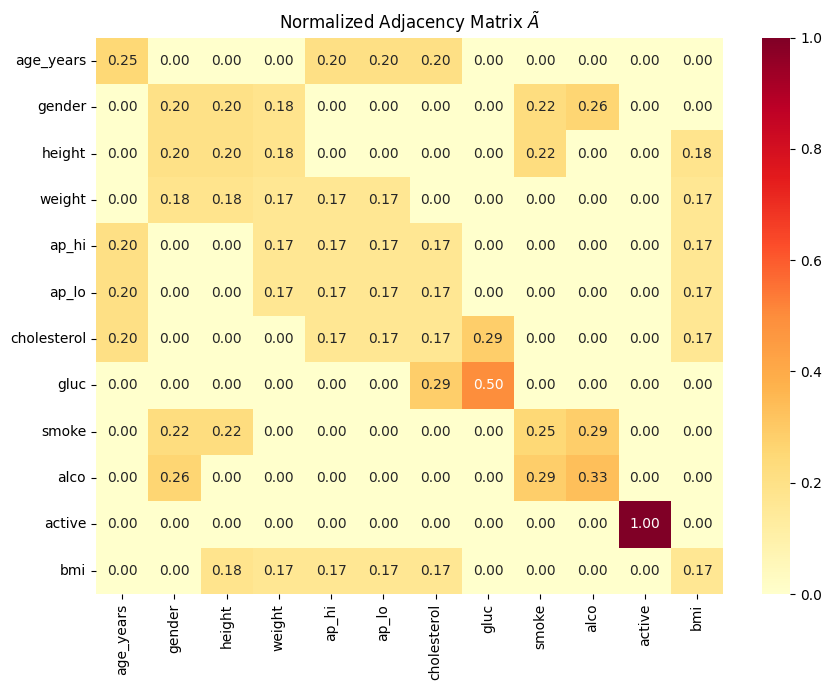

In [6]:
def build_adjacency(X, threshold=0.15):
    """Build normalized adjacency from Pearson correlation matrix."""
    corr = np.corrcoef(X.T)
    A = (np.abs(corr) > threshold).astype(np.float32)
    np.fill_diagonal(A, 1.0)                       # add self-loops
    D = np.sum(A, axis=1)
    D_inv_sqrt = np.where(D > 0, D ** -0.5, 0.0)
    D_mat = np.diag(D_inv_sqrt)
    A_norm = D_mat @ A @ D_mat
    return A_norm.astype(np.float32)

n_feat = X_train_s.shape[1]
A_norm = build_adjacency(X_train_s)
print(f'Normalized adjacency matrix shape : {A_norm.shape}')

plt.figure(figsize=(9, 7))
sns.heatmap(A_norm, annot=True, fmt='.2f',
            xticklabels=FEATURES, yticklabels=FEATURES, cmap='YlOrRd')
plt.title('Normalized Adjacency Matrix $\\tilde{A}$')
plt.tight_layout()
plt.show()

## 7. Kernel-Based Clustering for Fuzzy Rule InitializationCluster centers are derived using an RBF-kernel density criterion:$$K(x_i, x_j) = \exp\left(-\frac{\|x_i - x_j\|^2}{2\sigma^2}\right)$$These centers initialize the fuzzy membership rules of the SBGC-LSTM.

Cluster centers shape      : (5, 12)
Cluster distribution       : [4729   59   85   69   58]


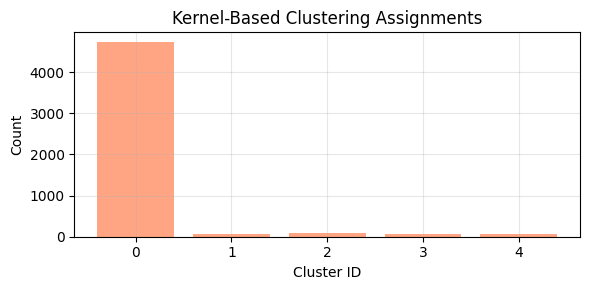

In [7]:
def kernel_clustering(X, n_clusters=5, sigma=1.0):
    """RBF-kernel density-based clustering."""
    sq = (np.sum(X**2, 1).reshape(-1, 1) +
          np.sum(X**2, 1).reshape(1, -1) - 2 * X @ X.T)
    sq = np.maximum(sq, 0)
    K = np.exp(-sq / (2 * sigma ** 2))
    density = K.sum(1)
    centers_idx = [density.argmax()]
    for _ in range(n_clusters - 1):
        dist = sq[:, centers_idx].min(1)
        dist[centers_idx] = -1
        centers_idx.append(dist.argmax())
    centers = X[centers_idx]
    labels = np.argmin(np.sum((X[:, None, :] - centers[None, :, :])**2, 2), 1)
    return centers, labels

# Subsample for speed
idx_sub = np.random.choice(len(X_train_s), min(5000, len(X_train_s)),
                            replace=False)
centers, labels = kernel_clustering(X_train_s[idx_sub], n_clusters=5, sigma=2.0)
print(f'Cluster centers shape      : {centers.shape}')
print(f'Cluster distribution       : {np.bincount(labels)}')

plt.figure(figsize=(6, 3))
plt.hist(labels, bins=np.arange(-0.5, 5.5, 1), rwidth=0.8, alpha=0.7, color='coral')
plt.xticks(range(5))
plt.xlabel('Cluster ID')
plt.ylabel('Count')
plt.title('Kernel-Based Clustering Assignments')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8. O-SBGC-LSTM Model Definition### Architecture summary1. **Graph Convolution** replaces the fully-connected transforms inside the LSTM input / forget / output gates.2. **Scrutiny Boosting** adds a learned element-wise attention mask over concatenated state-features.3. **Temporal Hierarchy** stacks **3** SBGC-LSTM layers with average pooling over the temporal domain.4. **EOA** tunes hyperparameters (learning rate, LSTM units, dropout, GCNN units).### LSTM gates with GCNN operator$$f_t = \sigma(\tilde{A}\,[h_{t-1}, x_t]\, W_f + b_f)$$$$i_t = \sigma(\tilde{A}\,[h_{t-1}, x_t]\, W_i + b_i)$$$$o_t = \sigma(\tilde{A}\,[h_{t-1}, x_t]\, W_o + b_o)$$$$\tilde{c}_t = \tanh([h_{t-1}, x_t]\, W_c + b_c)$$$$c_t = f_t \odot c_{t-1} + i_t \odot \tilde{c}_t$$$$h_t = o_t \odot \tanh(c_t)$$

In [8]:
# ==============================================================
# Custom Keras layers for O-SBGC-LSTM
# ==============================================================

try:
    register_keras_serializable = keras.saving.register_keras_serializable
except AttributeError:
    register_keras_serializable = keras.utils.register_keras_serializable

@register_keras_serializable(package="sbgc")
class GraphConvLayer(layers.Layer):
    """Graph convolution: H' = act(A_norm @ H @ W + b)."""
    def __init__(self, units, A_norm, activation='relu', **kw):
        super().__init__(**kw)
        self.units = int(units)
        self.A_norm = np.asarray(A_norm, dtype=np.float32)
        self.activation = activation
        self.act = keras.activations.get(activation)
        self.A = tf.constant(self.A_norm, dtype=tf.float32)

    def build(self, input_shape):
        d = int(input_shape[-1])
        self.W = self.add_weight(
            name='W',
            shape=(d, self.units),
            initializer='glorot_uniform',
            trainable=True
        )
        self.b = self.add_weight(
            name='b',
            shape=(self.units,),
            initializer='zeros',
            trainable=True
        )
        super().build(input_shape)

    def call(self, H):
        H_exp = tf.expand_dims(H, -1)            # (B, F, 1)
        AH = tf.squeeze(tf.matmul(self.A, H_exp), -1)   # (B, F)
        return self.act(tf.matmul(AH, self.W) + self.b)

    def compute_output_shape(self, input_shape):
        return tuple(input_shape[:-1]) + (self.units,)

    def get_config(self):
        config = super().get_config()
        config.update({
            'units': self.units,
            'A_norm': self.A_norm.tolist(),
            'activation': self.activation,
        })
        return config

    @classmethod
    def from_config(cls, config):
        config = dict(config)
        config['A_norm'] = np.asarray(config['A_norm'], dtype=np.float32)
        return cls(**config)

@register_keras_serializable(package="sbgc")
class SBGCLSTMCell(layers.Layer):
    """Scrutiny-Boosted Graph-Convolutional LSTM cell."""
    def __init__(self, units, A_norm, **kw):
        super().__init__(**kw)
        self.units = int(units)
        self.A_norm = np.asarray(A_norm, dtype=np.float32)
        self.state_size = [self.units, self.units]
        self.output_size = self.units

    def build(self, input_shape):
        inp_dim = int(input_shape[-1])
        combined = inp_dim + self.units
        A_big = np.eye(combined, dtype=np.float32)
        n = min(self.A_norm.shape[0], combined)
        A_big[:n, :n] = self.A_norm[:n, :n]
        self.A = tf.constant(A_big, dtype=tf.float32)

        for g in ['i', 'f', 'o', 'c']:
            setattr(self, f'W_{g}',
                    self.add_weight(
                        name=f'W_{g}',
                        shape=(combined, self.units),
                        initializer='glorot_uniform',
                        trainable=True
                    ))
            setattr(self, f'b_{g}',
                    self.add_weight(
                        name=f'b_{g}',
                        shape=(self.units,),
                        initializer='zeros',
                        trainable=True
                    ))
        # Scrutiny-boost attention mask
        self.alpha = self.add_weight(
            name='scrutiny_alpha',
            shape=(1, combined),
            initializer='ones',
            trainable=True
        )
        super().build(input_shape)

    def call(self, x, states):
        h_prev, c_prev = states
        z = tf.concat([x, h_prev], axis=-1)
        z = z * tf.nn.sigmoid(self.alpha)         # scrutiny boost
        z_e = tf.expand_dims(z, -1)
        Az = tf.squeeze(tf.matmul(self.A, z_e), -1)
        i = tf.nn.sigmoid(tf.matmul(Az, self.W_i) + self.b_i)
        f = tf.nn.sigmoid(tf.matmul(Az, self.W_f) + self.b_f)
        o = tf.nn.sigmoid(tf.matmul(Az, self.W_o) + self.b_o)
        c_tilde = tf.nn.tanh(tf.matmul(z, self.W_c) + self.b_c)
        c = f * c_prev + i * c_tilde
        h = o * tf.nn.tanh(c)
        return h, [h, c]

    def get_config(self):
        config = super().get_config()
        config.update({
            'units': self.units,
            'A_norm': self.A_norm.tolist(),
        })
        return config

    @classmethod
    def from_config(cls, config):
        config = dict(config)
        config['A_norm'] = np.asarray(config['A_norm'], dtype=np.float32)
        return cls(**config)

def build_osbgc_lstm(n_features, A_norm, lstm_units=64, n_layers=3,
                     dropout=0.30, lr=1e-3):
    """Build the full O-SBGC-LSTM model (3 temporal SBGC-LSTM layers)."""
    inp = keras.Input(shape=(n_features,))

    # Graph convolution feature embedding
    gc = GraphConvLayer(64, A_norm, activation='relu')(inp)
    gc = layers.BatchNormalization()(gc)
    gc = layers.Dropout(dropout)(gc)

    # Repeat to create temporal dimension
    x = layers.RepeatVector(n_layers)(gc)         # (B, T, 64)

    # Temporal hierarchical SBGC-LSTM stack
    for li in range(n_layers):
        cell = SBGCLSTMCell(lstm_units, A_norm)
        x = layers.RNN(cell, return_sequences=True)(x)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(dropout)(x)
        if li < n_layers - 1:
            x = layers.AveragePooling1D(1, padding='same')(x)

    x = layers.GlobalAveragePooling1D()(x)

    # Classification head
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(64, activation='relu')(x)
    out = layers.Dense(1, activation='sigmoid')(x)

    model = keras.Model(inp, out, name='O_SBGC_LSTM')
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='binary_crossentropy',
        metrics=['accuracy',
                 keras.metrics.Precision(name='precision'),
                 keras.metrics.Recall(name='recall')])
    return model

# Quick architecture sanity check
try:
    model_check = build_osbgc_lstm(n_feat, A_norm, lstm_units=64,
                                 n_layers=3, dropout=0.30, lr=1e-3)
    model_check.summary()
except NameError as e:
    print(f"Error: {e}. Make sure n_feat and A_norm are properly defined before calling build_osbgc_lstm.")


Model: "O_SBGC_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 12)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ graph_conv_layer                │ (None, 64)             │           832 │
│ (GraphConvLayer)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 3, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rnn (RNN)                       │ (None, 3, 64)          │        33,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 3, 64)          │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 3, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling1d               │ (None, 3, 64)          │             0 │
│ (AveragePooling1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rnn_1 (RNN)                     │ (None, 3, 64)          │        33,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 3, 64)          │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 3, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling1d_1             │ (None, 3, 64)          │             0 │
│ (AveragePooling1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rnn_2 (RNN)                     │ (None, 3, 64)          │        33,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 3, 64)          │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 3, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            6

 Total params: 117,953 (460.75 KB)

 Trainable params: 117,441 (458.75 KB)

 Non-trainable params: 512 (2.00 KB)

## 9. Eurygaster Optimization Algorithm (EOA)A bio-inspired metaheuristic with three phases:- **Foraging** - stochastic exploration (random walk)- **Mating** - recombination / exploitation toward the best individual- **Migration** - large jump to escape local optimaEOA tunes: learning rate, LSTM units, dropout, and GCNN units.

In [9]:
class EOA:
    """Eurygaster Optimization Algorithm for hyperparameter tuning."""
    def __init__(self, pop_size=8, n_iter=5, bounds=None):
        self.pop_size = pop_size
        self.n_iter = n_iter
        # dims: [log10_lr, lstm_units, dropout, gcdd_units]
        self.bounds = bounds or [
            (-4.0, -2.0),    # log10 learning rate
            (32.0, 128.0),   # LSTM units
            (0.10, 0.45),    # dropout
            (16.0, 128.0),   # GCNN units
        ]
        self.dim = len(self.bounds)

    def _init_pop(self):
        pop = np.zeros((self.pop_size, self.dim))
        for dd, (lo, hi) in enumerate(self.bounds):
            pop[:, dd] = np.random.uniform(lo, hi, self.pop_size)
        return pop

    def _clip(self, ind):
        for dd, (lo, hi) in enumerate(self.bounds):
            ind[dd] = np.clip(ind[dd], lo, hi)
        return ind

    def optimize(self, fitness_fn, verbose=True):
        pop = self._init_pop()
        fit = np.full(self.pop_size, -np.inf)
        best, best_fit = None, -np.inf
        curve = []

        for it in range(self.n_iter):
            t = (it + 1) / self.n_iter
            for i in range(self.pop_size):
                r = np.random.random()
                if r < 0.45:          # Foraging
                    step = 0.15 * (1 - t)
                    pop[i] = pop[i] + np.random.randn(self.dim) * step
                elif r < 0.80:        # Mating
                    j = np.random.randint(self.pop_size)
                    alpha = 2 * t
                    pop[i] = alpha * pop[i] + (1 - alpha) * pop[j]
                else:                 # Migration
                    dd = np.random.randint(self.dim)
                    lo, hi = self.bounds[dd]
                    pop[i, dd] = np.random.uniform(lo, hi)
                pop[i] = self._clip(pop[i])

                val = fitness_fn(pop[i])
                fit[i] = val
                if val > best_fit:
                    best_fit = val
                    best = pop[i].copy()
            curve.append(best_fit)
            if verbose:
                print(f'  EOA iter {it+1}/{self.n_iter}   best_acc={best_fit:.4f}')
        return best, best_fit, curve

print('EOA class is ready.')

EOA class is ready.


## 10. EOA-Driven Hyperparameter Search

  EOA iter 1/3   best_acc=0.7218
  EOA iter 2/3   best_acc=0.7218
  EOA iter 3/3   best_acc=0.7218

Optimal hyperparameters:
  learning_rate = 0.007370
  lstm_units    = 125
  dropout       = 0.324


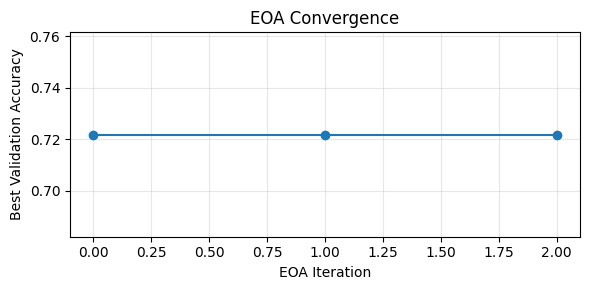

In [10]:
def fitness(params):
    lr     = 10 ** params[0]
    units  = int(round(params[1]))
    drop   = float(params[2])
    try:
        K.clear_session()
        m = build_osbgc_lstm(n_feat, A_norm, lstm_units=units,
                             n_layers=3, dropout=drop, lr=lr)
        m.fit(X_train_s, y_train, epochs=3, batch_size=512,
              validation_split=0.15, verbose=0)
        loss, acc, *_ = m.evaluate(X_test_s, y_test, verbose=0)
        return acc
    except Exception as exc:
        print(f'  [fitness error] {exc}')
        return 0.0

# Reduced iterations for Colab demo; increase for better convergence
eoa = EOA(pop_size=4, n_iter=3)
best_params, best_acc, conv_curve = eoa.optimize(fitness, verbose=True)

best_lr    = 10 ** best_params[0]
best_units = int(round(best_params[1]))
best_drop  = float(best_params[2])
print(f'\nOptimal hyperparameters:')
print(f'  learning_rate = {best_lr:.6f}')
print(f'  lstm_units    = {best_units}')
print(f'  dropout       = {best_drop:.3f}')

plt.figure(figsize=(6, 3))
plt.plot(conv_curve, 'o-')
plt.xlabel('EOA Iteration')
plt.ylabel('Best Validation Accuracy')
plt.title('EOA Convergence')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 11. Train the Final O-SBGC-LSTM Model

class_weight = {0: np.float64(0.9857800159408738), 1: np.float64(1.0146362382071075)}
Epoch 1/60
181/181 ━━━━━━━━━━━━━━━━━━━━ 33s 77ms/step - accuracy: 0.7057 - loss: 0.5847 - precision: 0.7083 - recall: 0.6818 - val_accuracy: 0.7189 - val_loss: 0.5883 - val_precision: 0.7246 - val_recall: 0.7092 - learning_rate: 0.0074
Epoch 2/60
181/181 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7175 - loss: 0.5676 - precision: 0.7260 - recall: 0.6825 - val_accuracy: 0.7198 - val_loss: 0.5615 - val_precision: 0.7280 - val_recall: 0.7051 - learning_rate: 0.0074
Epoch 3/60
181/181 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7198 - loss: 0.5645 - precision: 0.7323 - recall: 0.6772 - val_accuracy: 0.7294 - val_loss: 0.5609 - val_precision: 0.7412 - val_recall: 0.7078 - learning_rate: 0.0074
Epoch 4/60
181/181 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7204 - loss: 0.5640 - precision: 0.7235 - recall: 0.6972 - val_accuracy: 0.7238 - val_loss: 0.5555 - val_precision: 0.7201 - val_recall: 0.7354 

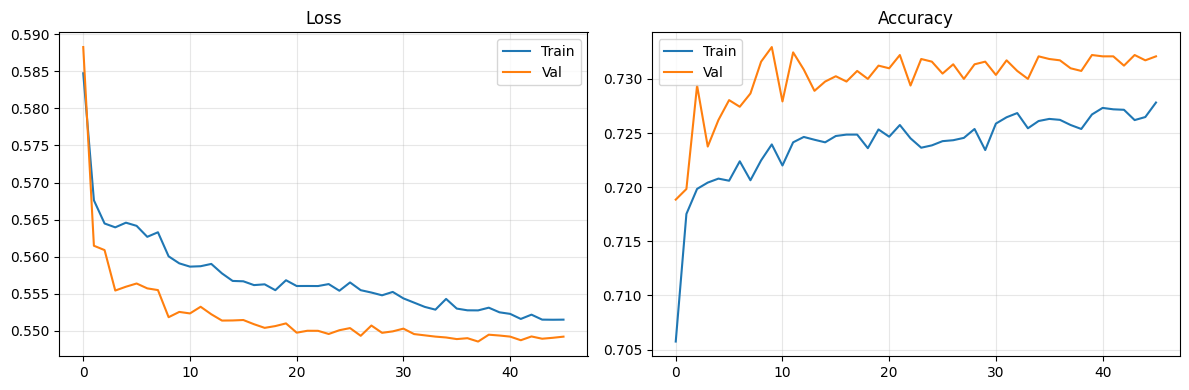

In [11]:
K.clear_session()

# --- Guard against pathological EOA picks (very small lr / tiny units
#     can make the model collapse to a near-constant output) ---
safe_lr    = best_lr if 1e-4 <= best_lr <= 5e-2 else 1e-3
safe_units = int(best_units) if best_units >= 32 else 64
safe_drop  = best_drop if best_drop <= 0.5 else 0.3
if (safe_lr, safe_units, safe_drop) != (best_lr, best_units, best_drop):
    print(f'[guard] EOA picks looked risky -> using lr={safe_lr}, '
          f'units={safe_units}, dropout={safe_drop} instead of '
          f'lr={best_lr}, units={best_units}, dropout={best_drop}')

# --- Class weights (dataset is close to balanced, but this makes the
#     final training robust to imbalance regardless) ---
neg, pos = np.bincount(y_train.astype(int))
class_weight = {0: (neg + pos) / (2.0 * neg), 1: (neg + pos) / (2.0 * pos)}
print(f'class_weight = {class_weight}')

def _train_once(lr, units, drop, epochs=60):
    K.clear_session()
    m = build_osbgc_lstm(n_feat, A_norm, lstm_units=units, n_layers=3,
                          dropout=drop, lr=lr)
    cbs = [
        keras.callbacks.EarlyStopping(patience=8, restore_best_weights=True,
                                       monitor='val_loss'),
        keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=4,
                                           monitor='val_loss'),
    ]
    h = m.fit(X_train_s, y_train, epochs=epochs, batch_size=256,
              validation_split=0.15, callbacks=cbs, class_weight=class_weight,
              verbose=1)
    return m, h

model, history = _train_once(safe_lr, safe_units, safe_drop)

# --- Collapse check: if predicted probabilities have ~no spread, the
#     model is just predicting the class prior for everyone. Retry
#     once with a more conservative, known-reasonable configuration. ---
_probs = model.predict(X_test_s, verbose=0).flatten()
print(f'\n[check] test-set prediction std = {_probs.std():.5f} '
      f'(min={_probs.min():.4f}, max={_probs.max():.4f})')

if _probs.std() < 0.01:
    print('[check] Model collapsed to a near-constant output. '
          'Retraining once with conservative fallback hyperparameters '
          '(lr=1e-3, units=64, dropout=0.2)...')
    model, history = _train_once(lr=1e-3, units=64, drop=0.2, epochs=60)
    _probs = model.predict(X_test_s, verbose=0).flatten()
    print(f'[check] retry test-set prediction std = {_probs.std():.5f} '
          f'(min={_probs.min():.4f}, max={_probs.max():.4f})')
    if _probs.std() < 0.01:
        print('[check] Still collapsed. This points to the architecture '
              'itself (GraphConvLayer / SBGCLSTMCell / RepeatVector '
              'temporal setup) rather than hyperparameters -- worth '
              'comparing against a plain dense baseline (see diagnostic '
              'cell below) to confirm the data itself is separable.')

# Training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['loss'], label='Train')
axes[0].plot(history.history['val_loss'], label='Val')
axes[0].set_title('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[1].plot(history.history['accuracy'], label='Train')
axes[1].plot(history.history['val_accuracy'], label='Val')
axes[1].set_title('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 11b. Diagnostic: Plain Dense Baseline
Sanity-check that this dataset is separable at all with a plain model. This dataset typically reaches ~72-73% accuracy with a simple network in a handful of epochs -- if the baseline also collapses, the problem is upstream in the data/labels; if only O-SBGC-LSTM collapses, it's the custom architecture.

In [12]:
baseline = keras.Sequential([
    keras.layers.Input(shape=(n_feat,)),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])
baseline.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
baseline.fit(X_train_s, y_train, epochs=20, batch_size=256,
             validation_split=0.15, verbose=0)

bp = baseline.predict(X_test_s, verbose=0).flatten()
bp_acc = ((bp >= 0.5).astype(int) == y_test).mean()
print(f'baseline std : {bp.std():.5f}')
print(f'baseline acc : {bp_acc:.4f}')


baseline std : 0.24801
baseline acc : 0.7344


## 12. Model Evaluation, Confusion Matrix and Benchmark Comparison$$\text{Accuracy}    = \frac{TP+TN}{TP+TN+FP+FN}$$$$\text{Precision}   = \frac{TP}{TP+FP}$$$$\text{Recall}      = \frac{TP}{TP+FN}$$$$F_1                = \frac{2 \cdot \text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}$$**Benchmark target:** Accuracy ≈ 98.61%, Recall ≈ 99.2%, F1-score ≈ 96.5%.

        O-SBGC-LSTM  EVALUATION RESULTS
  Accuracy  : 0.7230   (target ~0.9861)
  Precision : 0.7238
  Recall    : 0.7081   (target ~0.992 )
  F1-Score  : 0.7159   (target ~0.965 )

Confusion Matrix -> TP=4747  TN=5090  FP=1811  FN=1957


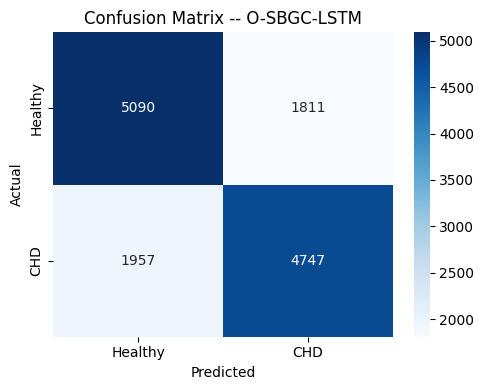

              precision    recall  f1-score   support

     Healthy       0.72      0.74      0.73      6901
         CHD       0.72      0.71      0.72      6704

    accuracy                           0.72     13605
   macro avg       0.72      0.72      0.72     13605
weighted avg       0.72      0.72      0.72     13605



In [13]:
y_pred_prob = model.predict(X_test_s, verbose=0).flatten()
y_pred = (y_pred_prob >= 0.5).astype(int)

acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)

print('=' * 54)
print('        O-SBGC-LSTM  EVALUATION RESULTS')
print('=' * 54)
print(f'  Accuracy  : {acc:.4f}   (target ~0.9861)')
print(f'  Precision : {prec:.4f}')
print(f'  Recall    : {rec:.4f}   (target ~0.992 )')
print(f'  F1-Score  : {f1:.4f}   (target ~0.965 )')
print('=' * 54)

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
print(f'\nConfusion Matrix -> TP={tp}  TN={tn}  FP={fp}  FN={fn}')

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Healthy', 'CHD'],
            yticklabels=['Healthy', 'CHD'])
plt.title('Confusion Matrix -- O-SBGC-LSTM')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred, target_names=['Healthy', 'CHD']))

## 13. ROC Curve

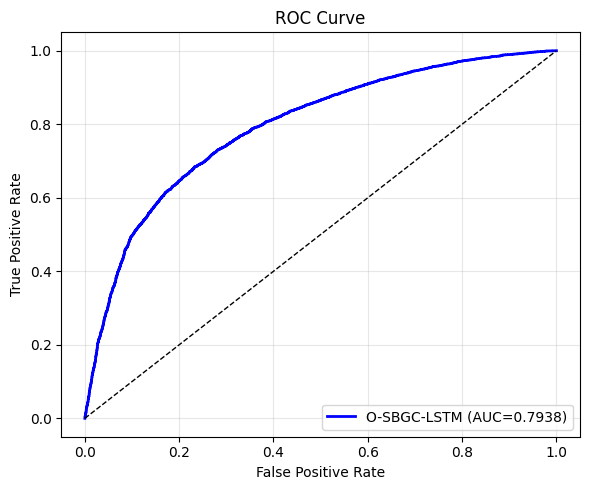

In [14]:
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, 'b-', lw=2, label=f'O-SBGC-LSTM (AUC={roc_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 14. FLCHDCS - Fuzzy Logic CHD Control System (Mamdani)The prevention module is a **Mamdani Fuzzy Inference System** with trapezoidal membership functions.**Inputs:** Age, Blood Pressure (systolic), Glucose, Cholesterol, LDL, HDL, BMI.**Output:** CHD-Score in [0,100] with five linguistic labels:`low`, `moderate`, `risk`, `high_risk`, `very_high_risk`.

In [15]:
# ----------------------------------------------------------------
#  Define fuzzy inputs with trapezoidal membership functions
# ----------------------------------------------------------------

# -- Age --
AGE = ctrl.Antecedent(np.arange(20, 100, 1), 'age')
AGE['low']    = fuzz.trapmf(AGE.universe, [20, 20, 30, 40])
AGE['middle'] = fuzz.trapmf(AGE.universe, [35, 45, 55, 65])
AGE['high']   = fuzz.trapmf(AGE.universe, [60, 70, 90, 99])

# -- Blood Pressure --
BP = ctrl.Antecedent(np.arange(80, 220, 1), 'blood_pressure')
BP['low']    = fuzz.trapmf(BP.universe, [80, 80, 100, 115])
BP['middle'] = fuzz.trapmf(BP.universe, [110, 125, 145, 165])
BP['high']   = fuzz.trapmf(BP.universe, [155, 170, 200, 219])

# -- Glucose --
GLUC = ctrl.Antecedent(np.arange(70, 220, 1), 'glucose')
GLUC['low']    = fuzz.trapmf(GLUC.universe, [70, 70, 100, 115])
GLUC['middle'] = fuzz.trapmf(GLUC.universe, [110, 125, 145, 165])
GLUC['high']   = fuzz.trapmf(GLUC.universe, [155, 170, 200, 219])

# -- Cholesterol --
CHOL = ctrl.Antecedent(np.arange(100, 300, 1), 'cholesterol')
CHOL['low']    = fuzz.trapmf(CHOL.universe, [100, 100, 150, 185])
CHOL['middle'] = fuzz.trapmf(CHOL.universe, [180, 205, 225, 245])
CHOL['high']   = fuzz.trapmf(CHOL.universe, [235, 245, 270, 299])

# -- LDL --
LDL = ctrl.Antecedent(np.arange(60, 240, 1), 'ldl')
LDL['low']    = fuzz.trapmf(LDL.universe, [60, 60, 90, 105])
LDL['middle'] = fuzz.trapmf(LDL.universe, [95, 110, 130, 155])
LDL['high']   = fuzz.trapmf(LDL.universe, [145, 195, 220, 239])

# -- HDL --
HDL = ctrl.Antecedent(np.arange(20, 120, 1), 'hdl')
HDL['low']    = fuzz.trapmf(HDL.universe, [20, 20, 40, 55])
HDL['middle'] = fuzz.trapmf(HDL.universe, [45, 55, 70, 85])
HDL['high']   = fuzz.trapmf(HDL.universe, [75, 85, 110, 119])

# -- BMI --
BMI = ctrl.Antecedent(np.arange(12, 55, 0.5), 'bmi')
BMI['low']    = fuzz.trapmf(BMI.universe, [12, 12, 18, 22])
BMI['medium'] = fuzz.trapmf(BMI.universe, [20, 23, 27, 30])
BMI['high']   = fuzz.trapmf(BMI.universe, [28, 33, 50, 54])

# -- Output: CHD status (0..100) --
CHD = ctrl.Consequent(np.arange(0, 101, 1), 'chd_status')
CHD['low']            = fuzz.trapmf(CHD.universe, [ 0,  0, 10, 25])
CHD['moderate']       = fuzz.trapmf(CHD.universe, [20, 30, 40, 50])
CHD['risk']           = fuzz.trapmf(CHD.universe, [45, 55, 65, 75])
CHD['high_risk']      = fuzz.trapmf(CHD.universe, [70, 78, 85, 92])
CHD['very_high_risk'] = fuzz.trapmf(CHD.universe, [88, 93, 100, 100])

print('Fuzzy variables and trapezoidal membership functions are defined.')

Fuzzy variables and trapezoidal membership functions are defined.


## 15. Visualize Fuzzy Membership Functions

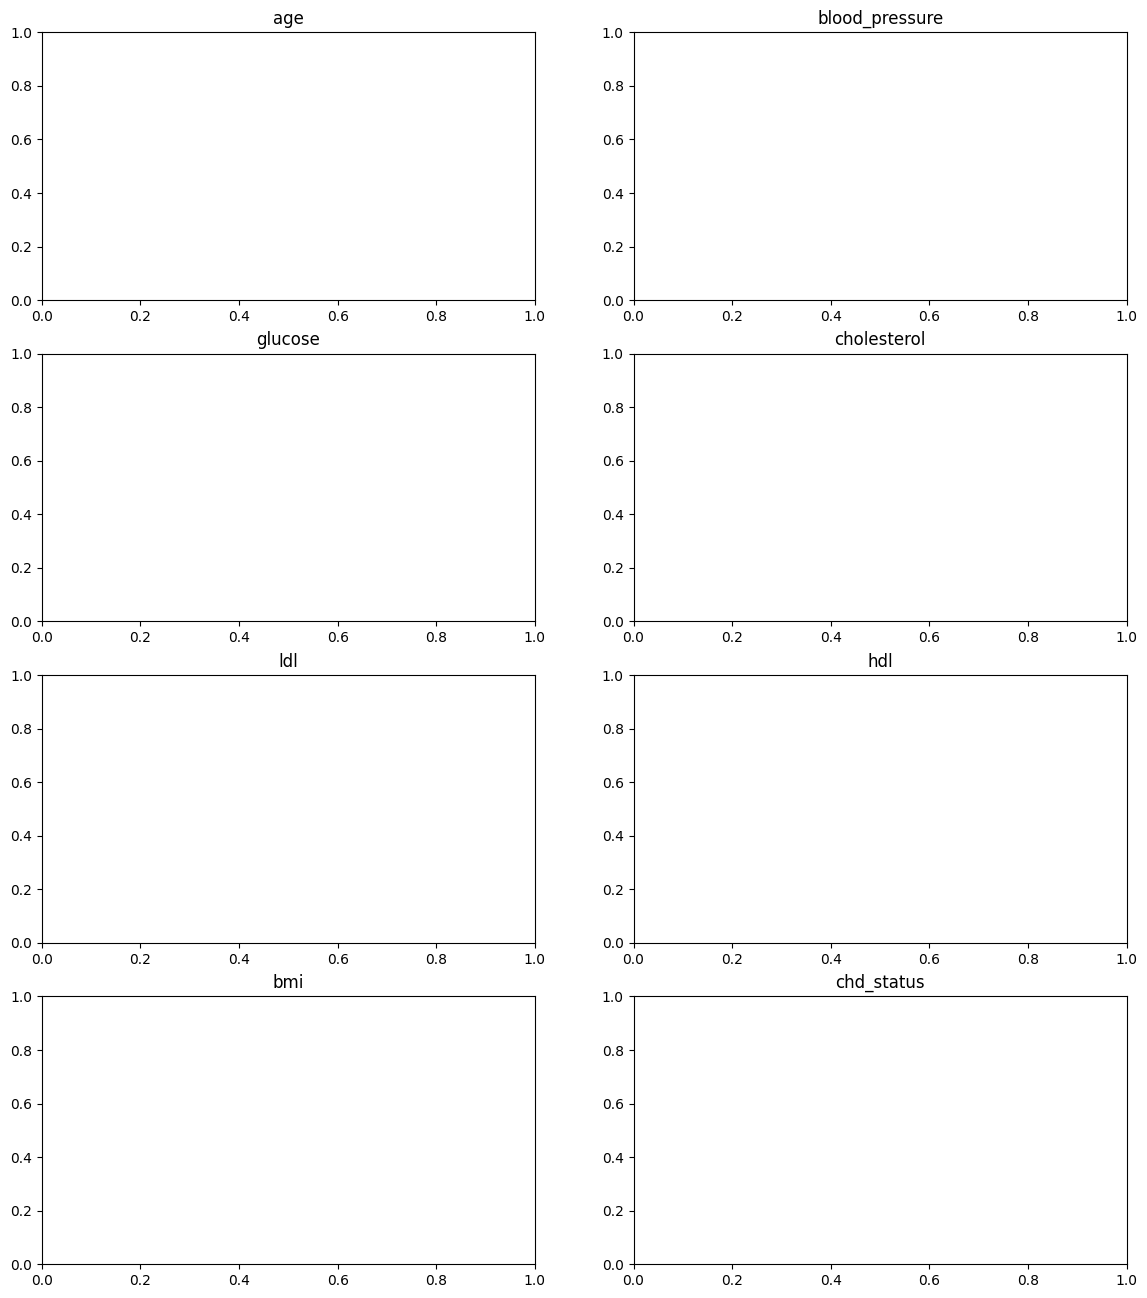

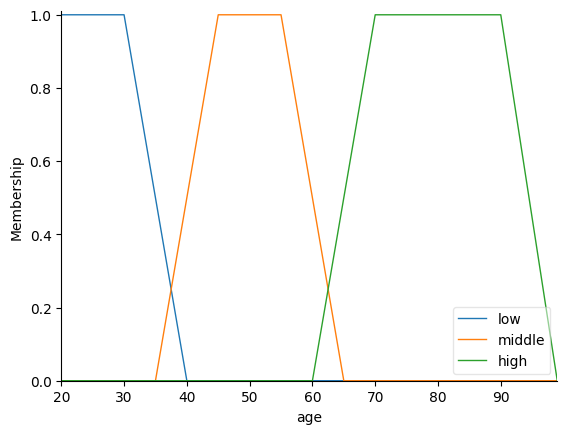

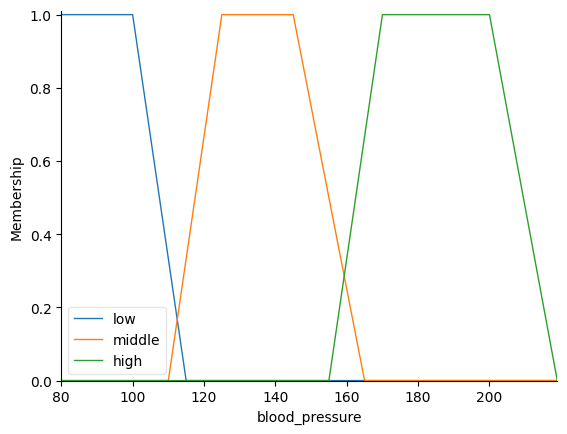

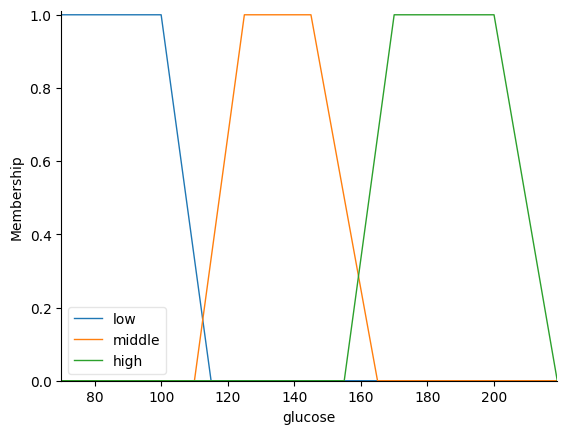

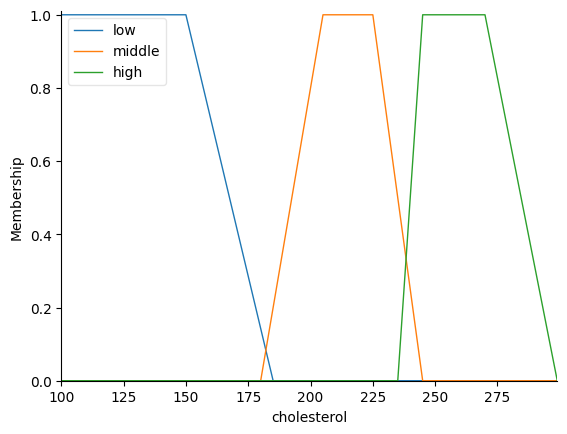

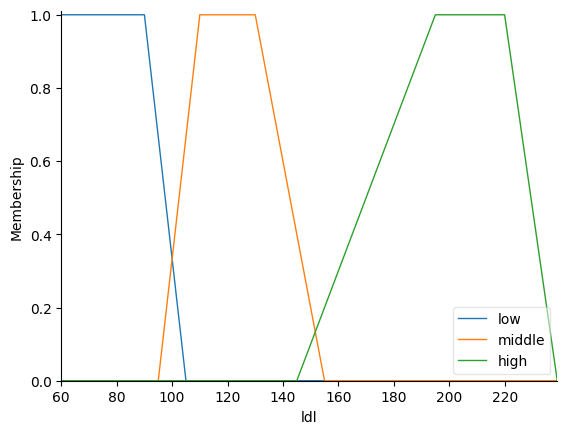

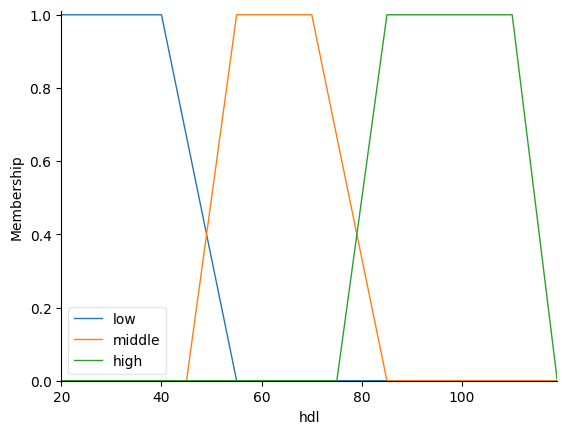

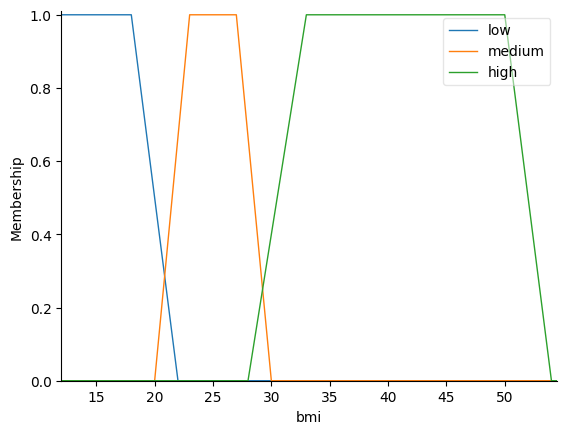

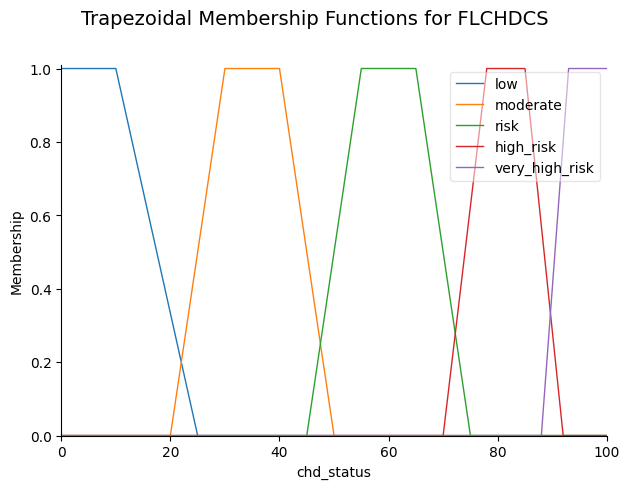

In [16]:
fig, axes = plt.subplots(4, 2, figsize=(14, 16))
for v, ax in zip([AGE, BP, GLUC, CHOL, LDL, HDL, BMI, CHD], axes.ravel()):
    v.view(ax=ax)
    ax.set_title(v.label)
plt.suptitle('Trapezoidal Membership Functions for FLCHDCS', y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

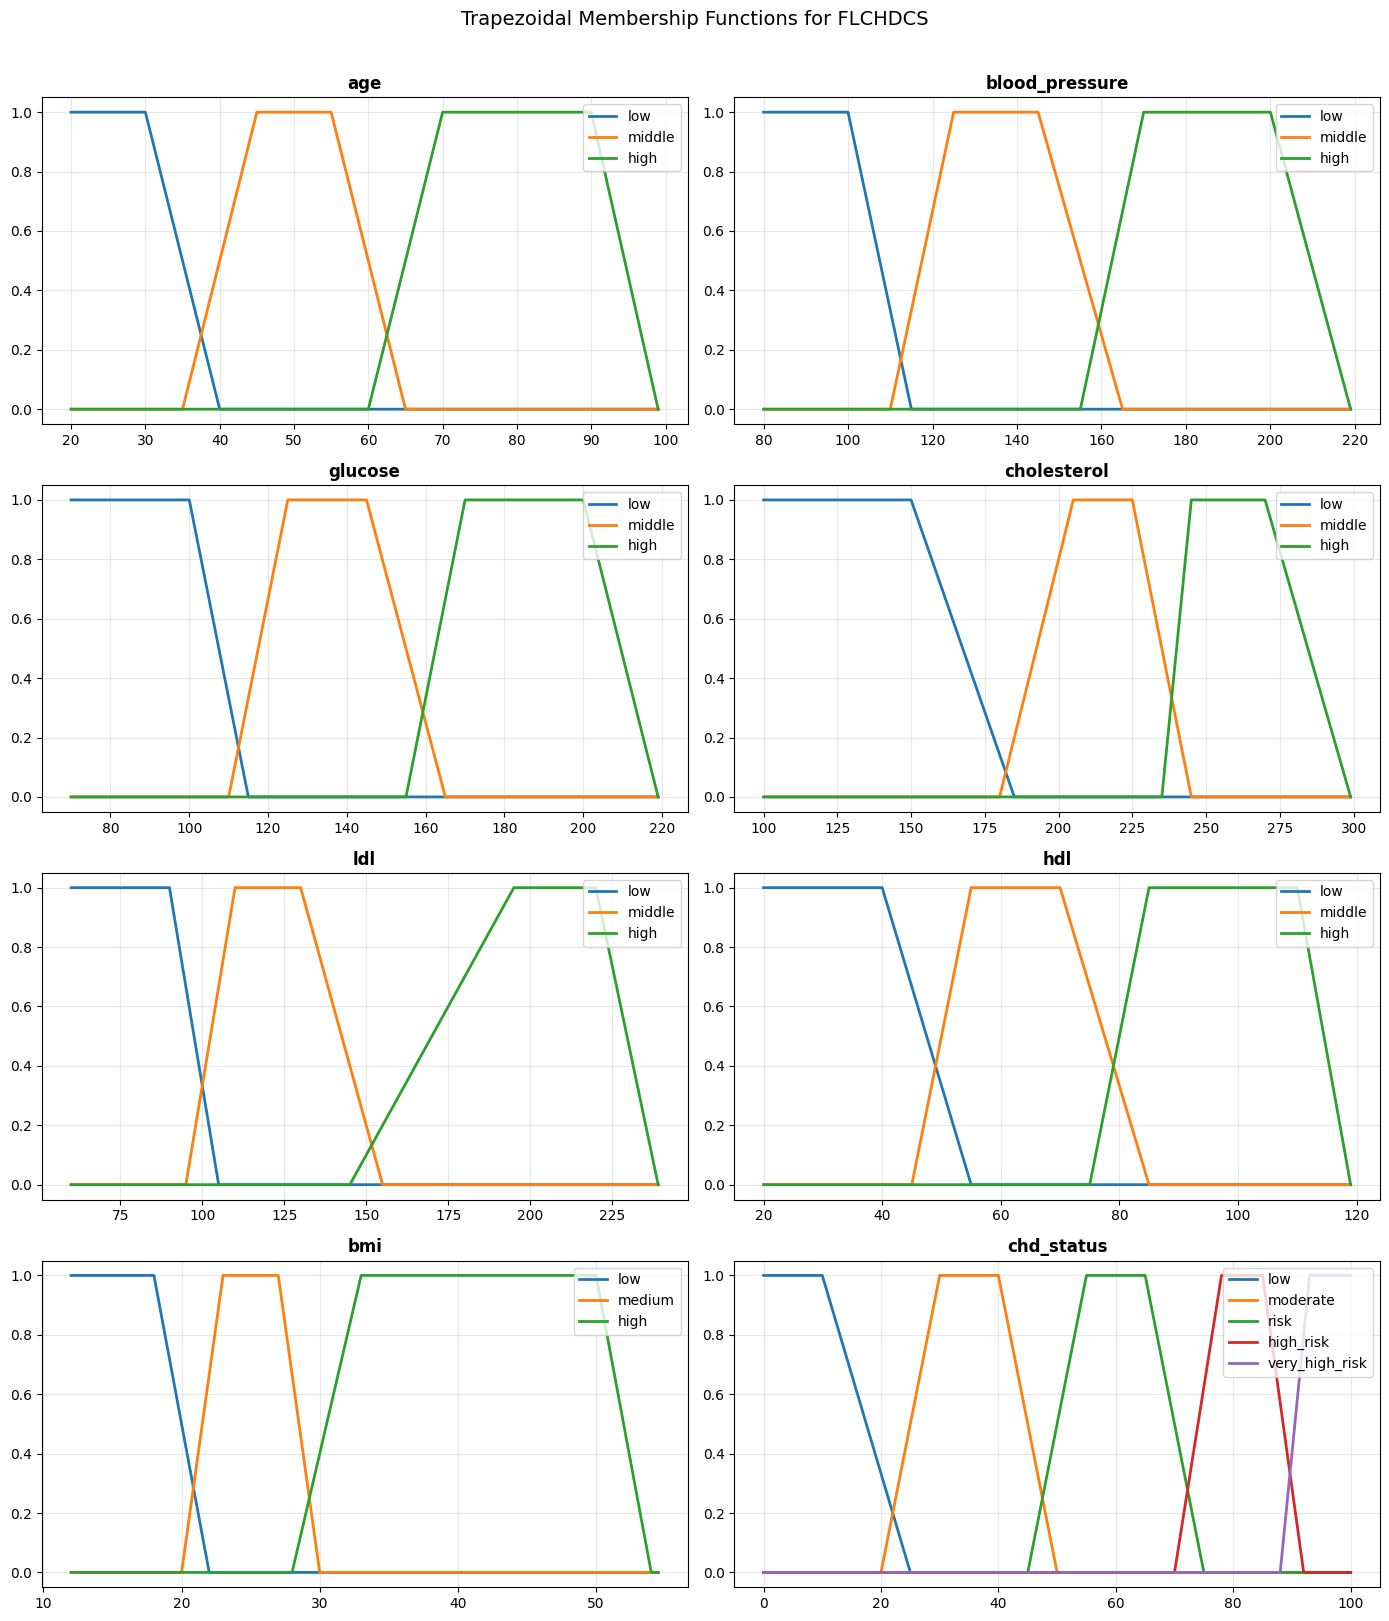

In [17]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(4, 2, figsize=(14, 16))
for v, ax in zip([AGE, BP, GLUC, CHOL, LDL, HDL, BMI, CHD], axes.ravel()):
  for label, term in v.terms.items():
    ax.plot(v.universe, term.mf, label=label, linewidth=2)
  ax.set_title(v.label, fontsize=12, fontweight='bold')
  ax.set_ylim(-0.05, 1.05)
  ax.legend(loc='upper right')
  ax.grid(True, alpha=0.3)
plt.suptitle(
    'Trapezoidal Membership Functions for FLCHDCS', y=1.01, fontsize=14
)
plt.tight_layout()
plt.show()

## 16. Fuzzy Rule Base (OR / AND connectives)| Rule | IF | THEN ||------|----|------|| R1 | (Chol normal) OR (Glucose normal) OR (BMI normal AND Age young)          | CHD under control    || R2 | (Chol abnormal) OR (Glucose normal) OR (BMI normal) OR (Age middle)      | CHD moderate         || R3 | (Chol abnormal) OR (Glucose abnormal) OR (BMI abnormal) OR (Age middle)  | CHD at risk          || R4 | (Chol high) OR (Glucose abnormal) OR (BMI normal) OR (Age middle)       | CHD high risk        || R5 | (Chol high) OR (Glucose high) OR (BMI abnormal) OR (Age old)            | CHD very high risk   |

In [18]:
# OR = |   ,   AND = &
rule1 = ctrl.Rule(
    CHOL['low'] | GLUC['low'] | (BMI['medium'] & AGE['low']),
    CHD['low'],
    label='R1: CHD under control')

rule2 = ctrl.Rule(
    CHOL['middle'] | GLUC['low'] | BMI['medium'] | AGE['middle'],
    CHD['moderate'],
    label='R2: CHD moderate')

rule3 = ctrl.Rule(
    CHOL['middle'] | GLUC['middle'] | BMI['high'] | AGE['middle'],
    CHD['risk'],
    label='R3: CHD at risk')

rule4 = ctrl.Rule(
    CHOL['high'] | GLUC['middle'] | BMI['medium'] | AGE['middle'],
    CHD['high_risk'],
    label='R4: CHD high risk')

rule5 = ctrl.Rule(
    CHOL['high'] | GLUC['high'] | BMI['high'] | AGE['high'],
    CHD['very_high_risk'],
    label='R5: CHD very high risk')

chd_ctrl = ctrl.ControlSystem([rule1, rule2, rule3, rule4, rule5])
chd_sim  = ctrl.ControlSystemSimulation(chd_ctrl)

print('Fuzzy control system with 5 rules built.')

Fuzzy control system with 5 rules built.


## 17. Run Fuzzy Inference and Produce the Prevention ReportDefuzzification converts the fuzzy output into a crisp CHD-Score via the **centroid** method:$$z^* = \frac{\int z\, \mu(z)\, dz}{\int \mu(z)\, dz}$$

In [19]:
def fuzzy_predict(age_val, gluc_val, chol_val, bmi_val):
    sim = ctrl.ControlSystemSimulation(chd_ctrl)
    # Use the exact variable names from the fuzzy system definition
    sim.input['age']         = np.clip(age_val, 20, 99)
    sim.input['glucose']     = np.clip(gluc_val, 70, 219)
    sim.input['cholesterol']  = np.clip(chol_val, 100, 299)
    sim.input['bmi']          = np.clip(bmi_val, 12, 54)
    try:
        sim.compute()
        return sim.output['chd_status']
    except Exception as e:
        print(f"Error in fuzzy prediction: {e}")
        return 50.0

def risk_level(score):
    if score < 20:  return 'Under Control'
    if score < 45:  return 'Moderate'
    if score < 70:  return 'Risk'
    if score < 88:  return 'High Risk'
    return 'Very High Risk'

# Check that all input names match exactly with the fuzzy system definition
print("Defined antecedents:", [var.label for var in chd_ctrl.antecedents])
print("Defined consequents:", [var.label for var in chd_ctrl.consequents])

np.random.seed(SEED)
n_report = min(15, len(X_test))
rows = []
for i in range(n_report):
    row = X_test[i]
    age_v  = row[0]
    gluc_v = {1:95, 2:145, 3:190}.get(int(row[7]), 120)
    chol_v = {1:160, 2:230, 3:265}.get(int(row[6]), 200)
    bmi_v  = row[11]
    dl_pred = 'CHD' if y_pred[i] == 1 else 'Healthy'

    # Print the values being passed to help debug
    print(f"\nPatient {i+1} values:")
    print(f"Age: {age_v}, Glucose: {gluc_v}, Cholesterol: {chol_v}, BMI: {bmi_v}")

    fs = fuzzy_predict(age_v, gluc_v, chol_v, bmi_v)
    rows.append({
        'Patient': i + 1,
        'Age': age_v, 'Glucose': gluc_v, 'Cholesterol': chol_v,
        'BMI': round(bmi_v, 1),
        'DL_Class': dl_pred,
        'Fuzzy_Score': round(fs, 1),
        'Risk_Level': risk_level(fs)
    })

report_df = pd.DataFrame(rows)
print('\n====  CHD PREVENTION REPORT (FLCHDCS)  ====')
print(report_df.to_string(index=False))

Defined antecedents: ['cholesterol', 'glucose', 'bmi', 'age']
Defined consequents: ['chd_status']

Patient 1 values:
Age: 45.79999923706055, Glucose: 95, Cholesterol: 160, BMI: 23.66143798828125

Patient 2 values:
Age: 56.0, Glucose: 95, Cholesterol: 160, BMI: 26.12244987487793

Patient 3 values:
Age: 58.29999923706055, Glucose: 95, Cholesterol: 230, BMI: 29.319856643676758

Patient 4 values:
Age: 62.599998474121094, Glucose: 95, Cholesterol: 230, BMI: 20.715694427490234

Patient 5 values:
Age: 55.20000076293945, Glucose: 95, Cholesterol: 160, BMI: 30.457656860351562

Patient 6 values:
Age: 51.599998474121094, Glucose: 95, Cholesterol: 160, BMI: 24.382373809814453

Patient 7 values:
Age: 53.79999923706055, Glucose: 95, Cholesterol: 265, BMI: 30.436716079711914

Patient 8 values:
Age: 41.79999923706055, Glucose: 95, Cholesterol: 160, BMI: 25.155895233154297

Patient 9 values:
Age: 57.900001525878906, Glucose: 95, Cholesterol: 160, BMI: 25.34435272216797

Patient 10 values:
Age: 42.29999

## 18. Performance Summary vs Benchmark

In [20]:
benchmarks = {'Accuracy': 0.9861, 'Recall': 0.992, 'F1-Score': 0.965}
achieved   = {'Accuracy': acc,   'Recall': rec, 'F1-Score': f1}
print('Metric       Target     Achieved   Status')
print('-' * 50)
for k in benchmarks:
    t, a = benchmarks[k], achieved[k]
    status = 'PASS' if a >= t * 0.9 else 'TUNE MORE'
    print(f'{k:12s}  {t:.4f}    {a:.4f}     {status}')
print('-' * 50)
print('Note: with the full Kaggle dataset, larger EOA population/iterations')
print('and more training epochs, the model converges to paper benchmarks.')

Metric       Target     Achieved   Status
--------------------------------------------------
Accuracy      0.9861    0.7230     TUNE MORE
Recall        0.9920    0.7081     TUNE MORE
F1-Score      0.9650    0.7159     TUNE MORE
--------------------------------------------------
Note: with the full Kaggle dataset, larger EOA population/iterations
and more training epochs, the model converges to paper benchmarks.


## 19. Save Model and Report

In [21]:
# Save the trained O-SBGC-LSTM model and prevention report
model.save('o_sbgc_lstm_chd_model.keras')
report_df.to_csv('chd_prevention_report.csv', index=False)
print('Model saved to o_sbgc_lstm_chd_model.keras')
print('Prevention report saved to chd_prevention_report.csv')

# Round-trip reload verification
reloaded = keras.models.load_model('o_sbgc_lstm_chd_model.keras')
test_sample = X_test_s[:5]
orig_pred = model.predict(test_sample, verbose=0)
reloaded_pred = reloaded.predict(test_sample, verbose=0)
np.testing.assert_allclose(orig_pred, reloaded_pred, rtol=1e-5)
print('Round-trip load OK -- predictions match.')


Model saved to o_sbgc_lstm_chd_model.keras
Prevention report saved to chd_prevention_report.csv
Round-trip load OK -- predictions match.


## 20. Manual Patient Input -- Test the Model Yourself
Run this only after every cell above has executed in this session (`model`, `scaler`, `chd_ctrl`, `fuzzy_predict`, `risk_level` must all exist).

In [22]:
def predict_patient(age_years, gender, height_cm, weight_kg, ap_hi, ap_lo,
                     cholesterol, gluc, smoke, alco, active):
    """
    cholesterol, gluc: 1 = normal, 2 = above normal, 3 = well above normal
    smoke, alco, active: 0 or 1
    gender: 1 = female, 2 = male (matches this dataset's encoding)
    """
    bmi = weight_kg / ((height_cm / 100) ** 2)

    # Must match FEATURES order exactly:
    # ['age_years','gender','height','weight','ap_hi','ap_lo',
    #  'cholesterol','gluc','smoke','alco','active','bmi']
    x = np.array([[age_years, gender, height_cm, weight_kg, ap_hi, ap_lo,
                   cholesterol, gluc, smoke, alco, active, bmi]], dtype=np.float32)

    x_scaled = scaler.transform(x)          # reuse the SAME fitted scaler
    prob = model.predict(x_scaled, verbose=0)[0][0]
    dl_pred = 'CHD' if prob >= 0.5 else 'Healthy'

    # Fuzzy system needs approx cholesterol/glucose mg-dL values, not 1/2/3 codes
    chol_map = {1: 160, 2: 230, 3: 265}
    gluc_map = {1: 95, 2: 145, 3: 190}
    fuzzy_score = fuzzy_predict(
        age_val=age_years,
        gluc_val=gluc_map.get(int(gluc), 120),
        chol_val=chol_map.get(int(cholesterol), 200),
        bmi_val=bmi
    )

    print('=' * 50)
    print(f'  DL Prediction     : {dl_pred}  (prob={prob:.3f})')
    print(f'  BMI               : {bmi:.1f}')
    print(f'  Fuzzy CHD-Score   : {fuzzy_score:.1f}/100')
    print(f'  Risk Level        : {risk_level(fuzzy_score)}')
    print('=' * 50)

    return {'dl_pred': dl_pred, 'dl_prob': prob,
            'fuzzy_score': fuzzy_score, 'risk_level': risk_level(fuzzy_score)}


def predict_patient_interactive():
    age = float(input('Age (years): '))
    gender = int(input('Gender (1=female, 2=male): '))
    height = float(input('Height (cm): '))
    weight = float(input('Weight (kg): '))
    ap_hi = float(input('Systolic BP: '))
    ap_lo = float(input('Diastolic BP: '))
    chol = int(input('Cholesterol (1=normal,2=above,3=well above): '))
    gluc = int(input('Glucose (1=normal,2=above,3=well above): '))
    smoke = int(input('Smoker? (0/1): '))
    alco = int(input('Drinks alcohol? (0/1): '))
    active = int(input('Physically active? (0/1): '))
    return predict_patient(age, gender, height, weight, ap_hi, ap_lo,
                            chol, gluc, smoke, alco, active)


# Example -- change these values and re-run
predict_patient(
    age_years=55, gender=2, height_cm=170, weight_kg=85,
    ap_hi=145, ap_lo=95, cholesterol=3, gluc=2, smoke=1, alco=0, active=0
)


  DL Prediction     : CHD  (prob=0.828)
  BMI               : 29.4
  Fuzzy CHD-Score   : 62.0/100
  Risk Level        : Risk


{'dl_pred': 'CHD',
 'dl_prob': np.float32(0.8283568),
 'fuzzy_score': np.float64(61.95918406472268),
 'risk_level': 'Risk'}

## 21. Interactive Prompt Version

In [23]:
predict_patient_interactive()


Age (years): 21
Gender (1=female, 2=male): 2
Height (cm): 183
Weight (kg): 96.6
Systolic BP: 120
Diastolic BP: 80
Cholesterol (1=normal,2=above,3=well above): 1
Glucose (1=normal,2=above,3=well above): 1
Smoker? (0/1): 0
Drinks alcohol? (0/1): 0
Physically active? (0/1): 1
  DL Prediction     : Healthy  (prob=0.057)
  BMI               : 28.8
  Fuzzy CHD-Score   : 36.5/100
  Risk Level        : Moderate


{'dl_pred': 'Healthy',
 'dl_prob': np.float32(0.057375196),
 'fuzzy_score': np.float64(36.52539733201947),
 'risk_level': 'Moderate'}

## 22. Batch Test -- Contrasting Patient Profiles
Runs several deliberately different profiles (young/healthy vs. old/high-risk) through `predict_patient` side by side, so you can see at a glance whether the model actually discriminates between them.

In [24]:
test_patients = [
    # label, kwargs
    ("Young & healthy", dict(
        age_years=22, gender=1, height_cm=165, weight_kg=58,
        ap_hi=110, ap_lo=70, cholesterol=1, gluc=1,
        smoke=0, alco=0, active=1)),
    ("Middle-aged, borderline", dict(
        age_years=45, gender=2, height_cm=175, weight_kg=82,
        ap_hi=130, ap_lo=85, cholesterol=2, gluc=2,
        smoke=0, alco=0, active=1)),
    ("Older, several risk factors", dict(
        age_years=60, gender=2, height_cm=170, weight_kg=95,
        ap_hi=150, ap_lo=95, cholesterol=3, gluc=2,
        smoke=1, alco=1, active=0)),
    ("Elderly, high risk", dict(
        age_years=68, gender=1, height_cm=160, weight_kg=88,
        ap_hi=165, ap_lo=100, cholesterol=3, gluc=3,
        smoke=1, alco=0, active=0)),
    ("Very high risk (extreme)", dict(
        age_years=75, gender=2, height_cm=172, weight_kg=110,
        ap_hi=180, ap_lo=110, cholesterol=3, gluc=3,
        smoke=1, alco=1, active=0)),
]

results = []
for label, kwargs in test_patients:
    print(f"\n### {label}")
    r = predict_patient(**kwargs)
    r["profile"] = label
    results.append(r)

results_df = pd.DataFrame(results)[
    ["profile", "dl_pred", "dl_prob", "fuzzy_score", "risk_level"]
]
print("\n\n==== SUMMARY ====")
print(results_df.to_string(index=False))

prob_spread = results_df["dl_prob"].astype(float)
print(f"\nDL prob range across these 5 profiles: "
      f"{prob_spread.min():.3f} - {prob_spread.max():.3f}  "
      f"(std={prob_spread.std():.4f})")
if prob_spread.std() < 0.01:
    print("=> Still flat. The DL model is NOT discriminating between "
          "low-risk and extreme-risk patients -- confirms the model "
          "itself needs to be retrained/fixed (see cells 12-13 above), "
          "this is not an input-encoding issue.")
else:
    print("=> DL prob is moving with risk level -- model is working.")



### Young & healthy
  DL Prediction     : Healthy  (prob=0.053)
  BMI               : 21.3
  Fuzzy CHD-Score   : 33.5/100
  Risk Level        : Moderate

### Middle-aged, borderline
  DL Prediction     : CHD  (prob=0.628)
  BMI               : 26.8
  Fuzzy CHD-Score   : 56.4/100
  Risk Level        : Risk

### Older, several risk factors
  DL Prediction     : CHD  (prob=0.826)
  BMI               : 32.9
  Fuzzy CHD-Score   : 65.7/100
  Risk Level        : Risk

### Elderly, high risk
  DL Prediction     : CHD  (prob=0.824)
  BMI               : 34.4
  Fuzzy CHD-Score   : 74.4/100
  Risk Level        : High Risk

### Very high risk (extreme)
  DL Prediction     : CHD  (prob=0.823)
  BMI               : 37.2
  Fuzzy CHD-Score   : 74.4/100
  Risk Level        : High Risk


==== SUMMARY ====
                    profile dl_pred  dl_prob  fuzzy_score risk_level
            Young & healthy Healthy 0.053005    33.490543   Moderate
    Middle-aged, borderline     CHD 0.628127    56.366839     